### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    message:Annotated[list, add_messages]

In [3]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")
llm.invoke("hi i am saran")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "hi i am saran"\n   - This is a simple greeting and introduction.\n   - Key information: Name = Saran\n   - Tone: Casual, friendly\n\n2.  **Identify Goal:**\n   - Acknowledge the greeting\n   - Use the provided name (Saran)\n   - Respond warmly and professionally\n   - Offer assistance\n\n3.  **Determine Response Structure:**\n   - Greet back\n   - Acknowledge name\n   - Ask how I can help\n   - Keep it concise and friendly\n\n4.  **Draft Response (Mental):**\n   Hi Saran! Nice to meet you. How can I assist you today?\n\n5.  **Refine Response:**\n   - Check tone: Friendly, professional\n   - Check accuracy: Uses correct name\n   - Check openness: Invites further conversation\n   - All good.\n\n6.  **Final Output Generation:** (matches the refined draft)\n   "Hi Saran! Nice to meet you. How can I help you today?"✅\n</think>\n\nHi Saran! Nice to meet you. How can I help you today? 😊'

### We Will start With Creating Nodes

In [5]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def chatbot(state:State):
    return {"message":[llm.invoke(state["message"])]}

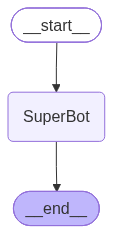

In [7]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",chatbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'message':"Hi,My name is Krish And I like cricket"},config)

{'message': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6585add4-0655-4175-b7a7-af1764719640'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Krish\n   - Interest: Cricket\n   - Greeting: "Hi,My name is Krish And I like cricket"\n\n2.  **Identify Key Elements:**\n   - Personal greeting requires a friendly response\n   - Acknowledge the name (Krish)\n   - Acknowledge the interest (cricket)\n   - Keep it conversational and open-ended to encourage further interaction\n\n3.  **Determine Response Goals:**\n   - Welcome Krish\n   - Acknowledge and validate his interest in cricket\n   - Ask an engaging follow-up question about cricket\n   - Maintain a friendly, enthusiastic tone\n   - Keep it concise\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Krish! Nice to meet you. Cricket is such an exciting sport—there\'s so much strategy, skill, and drama in every match.

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [10]:
chunks = graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates")

for chunlk in chunks:
    print(chunlk)

{'SuperBot': {'message': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user input is just "Hi,My name is Krish And I like cricket" (with a minor typo in the greeting, but clear in intent).\n2.  **Identify Key Elements:** \n   - Name: Krish\n   - Interest: Cricket\n   - No specific question asked\n3.  **Determine Response Goal:** \n   - Acknowledge the name and interest warmly\n   - Ask engaging follow-up questions to keep the conversation going\n   - Show knowledge/enthusiasm about cricket\n   - Keep it conversational and open-ended\n4.  **Draft Response (Mental Refinement):**\n   Hi Krish! Great to meet you. Cricket’s such an amazing sport—whether you\'re watching a nail-biting IPL match, following the World Cup, or playing with friends on a local ground, there’s so much to love about it. Are you more into watching or playing? And do you have a favorite team or cricketer you follow? 🏏✨\n5.  **Check Against Guidelines:** \n   - Friendly, 

In [11]:
chunks = graph_builder.stream({"message":"my name is saran as well"}, config=config, stream_mode="values")

for chunk in chunks:
    print(chunk)

{'message': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6585add4-0655-4175-b7a7-af1764719640'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Krish\n   - Interest: Cricket\n   - Greeting: "Hi,My name is Krish And I like cricket"\n\n2.  **Identify Key Elements:**\n   - Personal greeting requires a friendly response\n   - Acknowledge the name (Krish)\n   - Acknowledge the interest (cricket)\n   - Keep it conversational and open-ended to encourage further interaction\n\n3.  **Determine Response Goals:**\n   - Welcome Krish\n   - Acknowledge and validate his interest in cricket\n   - Ask an engaging follow-up question about cricket\n   - Maintain a friendly, enthusiastic tone\n   - Keep it concise\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Krish! Nice to meet you. Cricket is such an exciting sport—there\'s so much strategy, skill, and drama in every match. A

In [12]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'message': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "my name is saran as well"\n   - Previous context: User first said "My name is Krish And I like cricket", then followed up with "my name is saran as well"\n   - I already acknowledged both names and asked which one they prefer, plus asked about cricket preferences.\n   - Now the user just sent an empty message (or just a line break). Wait, looking at the prompt history:\n     - User: "Hi,My name is Krish And I like cricket"\n     - Me: Responded asking about team/player/format\n     - User: "" (empty)\n     - Me: Responded again, acknowledging both Krish and Saran, asking preference and cricket details\n     - User: "" (empty again)\n   - Actually, looking closely at the prompt history provided:\n     - Turn 1: User: "Hi,My name is Krish And I like cricket"\n     - Turn 2: Me: [Response]\n     - Turn 3: User: "" (empty)\n     - Turn 4: Me: [Response]\n    

In [13]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'message': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6585add4-0655-4175-b7a7-af1764719640'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Krish\n   - Interest: Cricket\n   - Greeting: "Hi,My name is Krish And I like cricket"\n\n2.  **Identify Key Elements:**\n   - Personal greeting requires a friendly response\n   - Acknowledge the name (Krish)\n   - Acknowledge the interest (cricket)\n   - Keep it conversational and open-ended to encourage further interaction\n\n3.  **Determine Response Goals:**\n   - Welcome Krish\n   - Acknowledge and validate his interest in cricket\n   - Ask an engaging follow-up question about cricket\n   - Maintain a friendly, enthusiastic tone\n   - Keep it concise\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Krish! Nice to meet you. Cricket is such an exciting sport—there\'s so much strategy, skill, and drama in every match. A

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [14]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ff9fc-598f-7740-8de9-32b2e6320bb9', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'message': []}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ff9fc-5992-7983-8181-4b5eef52aeb9', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:7c28beac-70c6-feac-2f57-f967dedd94ee'}, 'parent_ids': ['019ff9fc-598f-7740-8de9-32b2e6320bb9']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[]]}}, 'name': 'ChatGroq', 'tags': ['seq:step:1'], 'run_id': '019ff9fc-5993-73d3-a910-dba0d14586d1', 'metadata': {'thread_id': '3', 'ls_integration': 'langc

BadRequestError: Error code: 400 - {'error': {'message': "'messages' : minimum number of items is 1", 'type': 'invalid_request_error'}}